# OpenResty External I/O Analysis

This notebook focuses on the new OpenResty external I/O path:

- metadata fetches from the metadata sidecar
- Redis connect and command timings across access, content, and header-filter timer phases
- Kafka-mock publish latency from the async log-phase timer
- enriched OpenResty access logs for per-request diagnosis


In [1]:
from __future__ import annotations

from datetime import datetime, timedelta, timezone
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "python" / "src").exists():
    for candidate in ROOT.parents:
        if (candidate / "python" / "src").exists():
            ROOT = candidate
            break

sys.path.insert(0, str(ROOT / "python" / "src"))

from prometheus_tools import query_range

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

end = datetime.now(timezone.utc)
start = end - timedelta(minutes=30)
PROMETHEUS_URL = os.getenv("PROMETHEUS_URL", "http://localhost:9090")
KAFKA_MOCK_URL = os.getenv("KAFKA_MOCK_URL", "http://localhost:9300")
LOG_PATH = ROOT / "edge" / "logs" / "edge-access.log"

start, end, PROMETHEUS_URL, LOG_PATH


(datetime.datetime(2026, 4, 1, 20, 20, 28, 696925, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 4, 1, 20, 50, 28, 696925, tzinfo=datetime.timezone.utc),
 'http://localhost:9090',
 PosixPath('/workspaces/Development/K6_Playground/edge/logs/edge-access.log'))

In [2]:
def q(expression: str, step: str = "15s") -> pd.DataFrame:
    return query_range(expression, start, end, step=step, prometheus_url=PROMETHEUS_URL)

metadata_rate = q(
    'sum by (target_kind, outcome) (rate(openresty_edge_metadata_requests_total{route_family="openresty"}[1m]))'
)

metadata_avg = q(
    'sum by (target_kind, outcome) (rate(openresty_edge_metadata_duration_seconds_sum{route_family="openresty"}[1m])) / clamp_min(sum by (target_kind, outcome) (rate(openresty_edge_metadata_duration_seconds_count{route_family="openresty"}[1m])), 1e-9)'
)

redis_connect_avg = q(
    'sum by (phase, target_kind, outcome) (rate(openresty_edge_redis_connect_duration_seconds_sum{route_family="openresty"}[1m])) / clamp_min(sum by (phase, target_kind, outcome) (rate(openresty_edge_redis_connect_duration_seconds_count{route_family="openresty"}[1m])), 1e-9)'
)

redis_command_avg = q(
    'sum by (phase, target_kind, operation, outcome) (rate(openresty_edge_redis_command_duration_seconds_sum{route_family="openresty"}[1m])) / clamp_min(sum by (phase, target_kind, operation, outcome) (rate(openresty_edge_redis_command_duration_seconds_count{route_family="openresty"}[1m])), 1e-9)'
)

header_filter_p95 = q(
    'histogram_quantile(0.95, sum by (le, target_kind) (rate(openresty_edge_header_filter_duration_seconds_bucket{route_family="openresty"}[5m])))'
)

kafka_publish_p95 = q(
    'histogram_quantile(0.95, sum by (le, target_kind, outcome) (rate(openresty_edge_kafka_mock_publish_duration_seconds_bucket{route_family="openresty"}[5m])))'
)

{
    "metadata_rate_rows": len(metadata_rate),
    "metadata_avg_rows": len(metadata_avg),
    "redis_connect_avg_rows": len(redis_connect_avg),
    "redis_command_avg_rows": len(redis_command_avg),
    "header_filter_p95_rows": len(header_filter_p95),
    "kafka_publish_p95_rows": len(kafka_publish_p95),
}


{'metadata_rate_rows': 242,
 'metadata_avg_rows': 242,
 'redis_connect_avg_rows': 726,
 'redis_command_avg_rows': 2904,
 'header_filter_p95_rows': 242,
 'kafka_publish_p95_rows': 242}

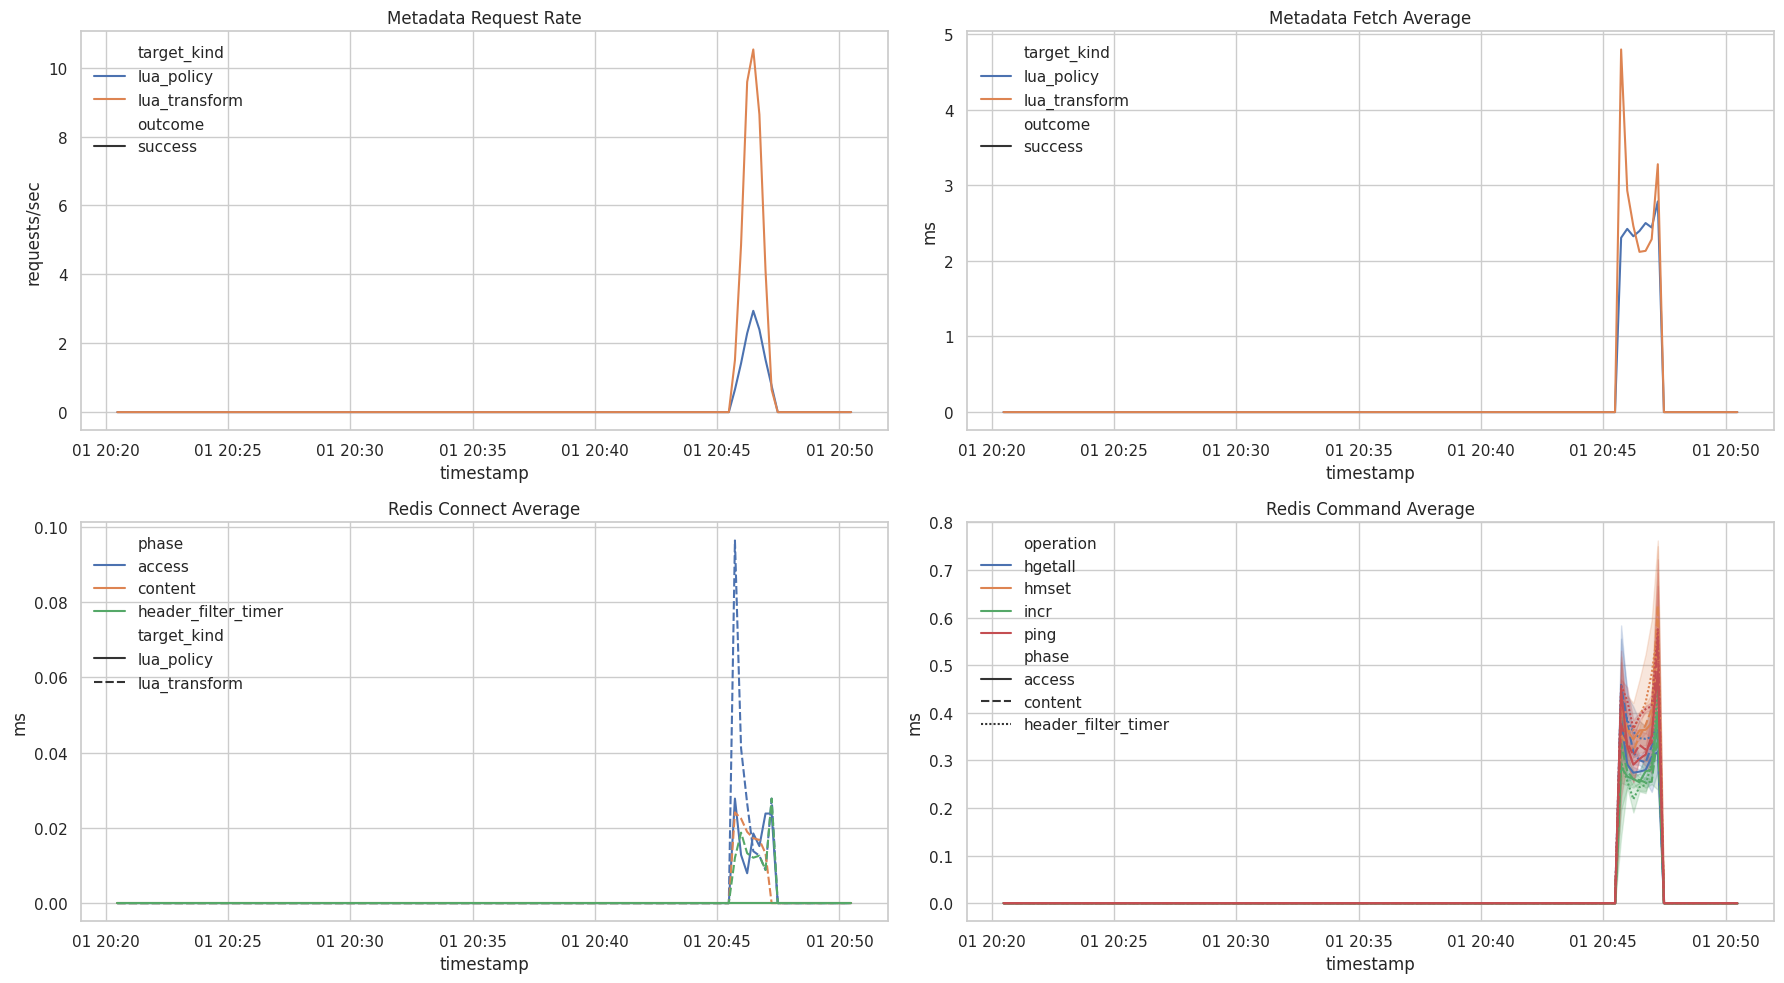

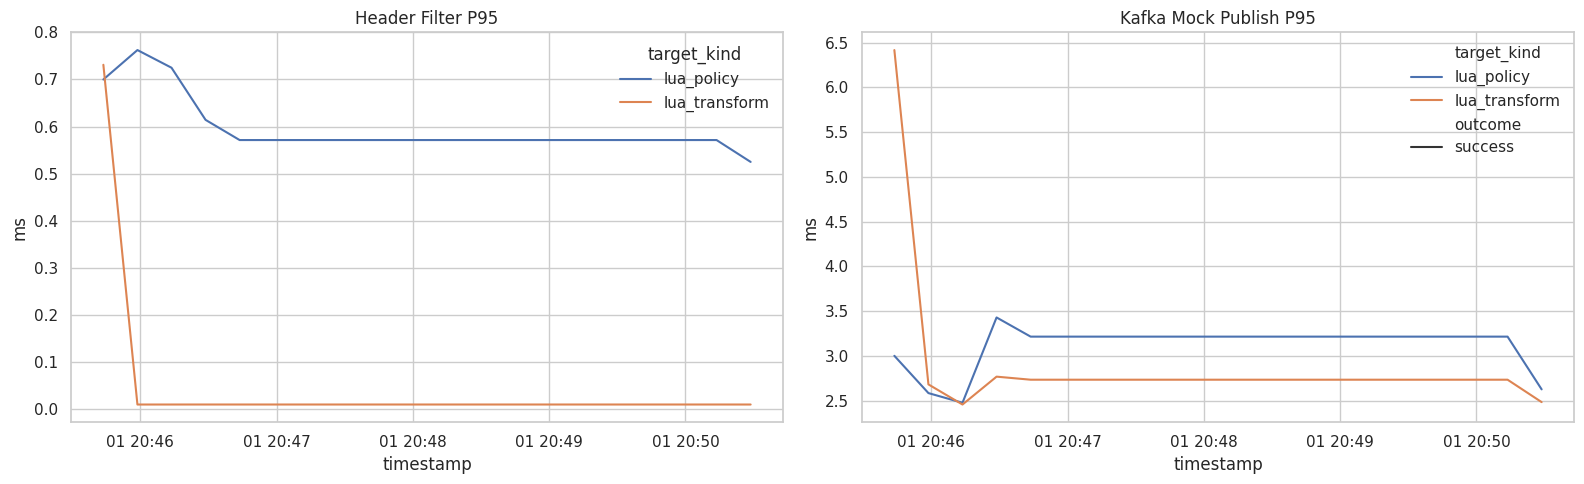

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

if not metadata_rate.empty:
    sns.lineplot(data=metadata_rate, x="timestamp", y="value", hue="target_kind", style="outcome", ax=axes[0, 0])
axes[0, 0].set_title("Metadata Request Rate")
axes[0, 0].set_ylabel("requests/sec")

if not metadata_avg.empty:
    temp = metadata_avg.copy()
    temp["ms"] = temp["value"] * 1000.0
    sns.lineplot(data=temp, x="timestamp", y="ms", hue="target_kind", style="outcome", ax=axes[0, 1])
axes[0, 1].set_title("Metadata Fetch Average")
axes[0, 1].set_ylabel("ms")

if not redis_connect_avg.empty:
    temp = redis_connect_avg.copy()
    temp["ms"] = temp["value"] * 1000.0
    sns.lineplot(data=temp, x="timestamp", y="ms", hue="phase", style="target_kind", ax=axes[1, 0])
axes[1, 0].set_title("Redis Connect Average")
axes[1, 0].set_ylabel("ms")

if not redis_command_avg.empty:
    temp = redis_command_avg.copy()
    temp["ms"] = temp["value"] * 1000.0
    temp = temp[temp["operation"].isin(["ping", "incr", "hmset", "hgetall"])]
    sns.lineplot(data=temp, x="timestamp", y="ms", hue="operation", style="phase", ax=axes[1, 1])
axes[1, 1].set_title("Redis Command Average")
axes[1, 1].set_ylabel("ms")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if not header_filter_p95.empty:
    temp = header_filter_p95.copy()
    temp["ms"] = temp["value"] * 1000.0
    sns.lineplot(data=temp, x="timestamp", y="ms", hue="target_kind", ax=axes[0])
axes[0].set_title("Header Filter P95")
axes[0].set_ylabel("ms")

if not kafka_publish_p95.empty:
    temp = kafka_publish_p95.copy()
    temp["ms"] = temp["value"] * 1000.0
    sns.lineplot(data=temp, x="timestamp", y="ms", hue="target_kind", style="outcome", ax=axes[1])
axes[1].set_title("Kafka Mock Publish P95")
axes[1].set_ylabel("ms")

plt.tight_layout()
plt.show()


In [4]:
edge_log = pd.read_json(LOG_PATH, lines=True)
openresty_log = edge_log.loc[edge_log["route_family"] == "openresty"].copy()

numeric_columns = [
    "request_time",
    "lua_access_ms",
    "lua_content_ms",
    "header_filter_ms",
    "metadata_fetch_ms",
    "redis_access_connect_ms",
    "redis_access_command_ms",
    "redis_content_connect_ms",
    "redis_content_command_ms",
    "lua_gc_delta_kb",
]

for column in numeric_columns:
    if column in openresty_log.columns:
        openresty_log[column] = pd.to_numeric(openresty_log[column], errors="coerce")

openresty_log[[
    "time",
    "target_kind",
    "metadata_outcome",
    "redis_access_outcome",
    "redis_content_outcome",
    "metadata_fetch_ms",
    "redis_access_connect_ms",
    "redis_access_command_ms",
    "redis_content_command_ms",
    "header_filter_ms",
    "lua_gc_delta_kb",
]].tail(20)


/tmp/ipykernel_34076/2938262623.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  edge_log = pd.read_json(LOG_PATH, lines=True)


,time,target_kind,metadata_outcome,redis_access_outcome,redis_content_outcome,metadata_fetch_ms,redis_access_connect_ms,redis_access_command_ms,redis_content_command_ms,header_filter_ms,lua_gc_delta_kb
10465,2026-04-01T20:46:24+00:00,lua_transform,success,success,success,11.0,0.0,2.0,2.0,0.0,93.320
10466,2026-04-01T20:46:24+00:00,lua_transform,success,success,success,5.0,0.0,2.0,5.0,0.0,71.543
10489,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,2.0,0.0,2.0,1.0,0.0,32.254
10490,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,1.0,0.0,2.0,1.0,0.0,19.375
10491,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,2.0,0.0,1.0,1.0,0.0,15.488
10492,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,2.0,0.0,2.0,1.0,0.0,21.445
10493,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,2.0,0.0,2.0,1.0,0.0,22.926
10494,2026-04-01T20:46:25+00:00,lua_policy,success,success,success,2.0,0.0,1.0,0.0,0.0,23.340
10497,2026-04-01T20:46:26+00:00,lua_transform,success,success,success,2.0,0.0,1.0,1.0,0.0,87.688
10498,2026-04-01T20:46:26+00:00,lua_transform,success,success,success,1.0,0.0,2.0,0.0,0.0,67.469


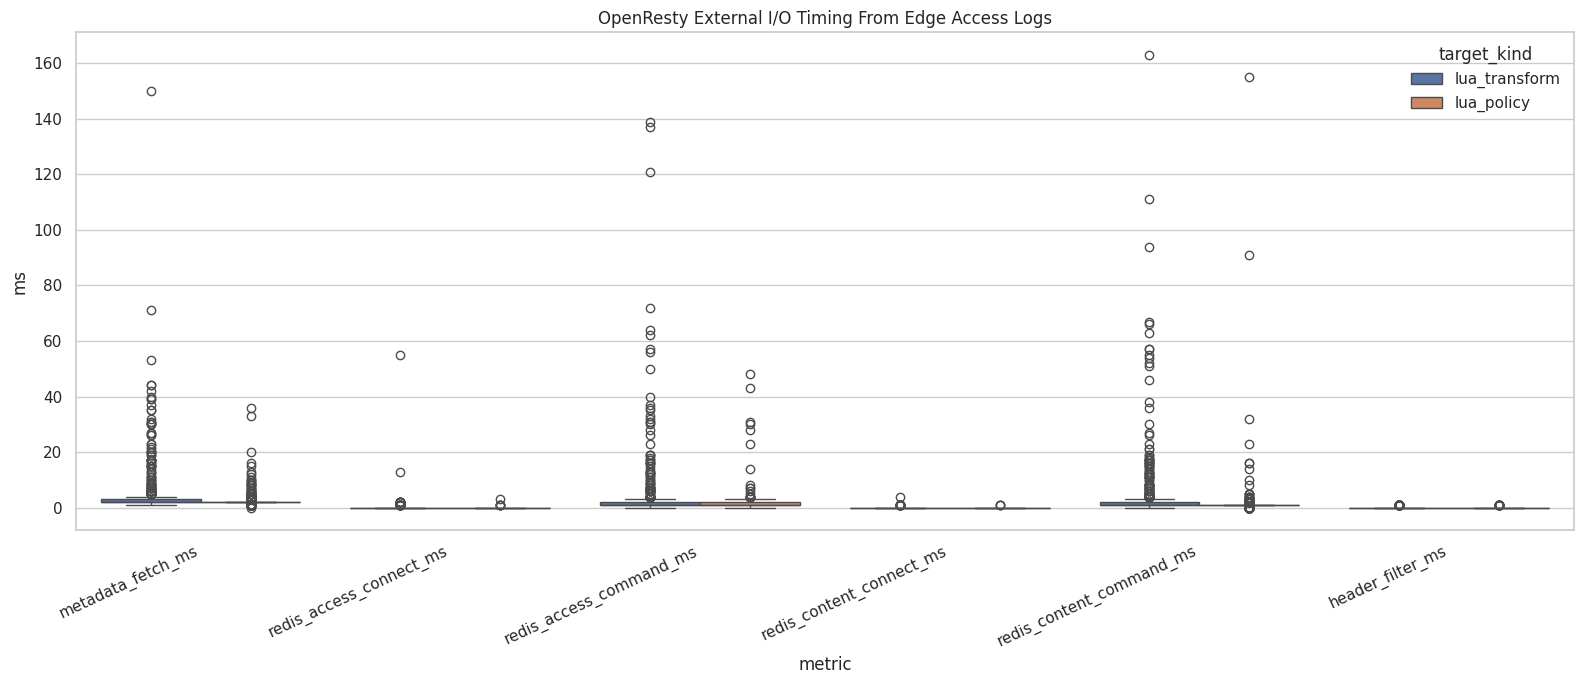

,received_at,host,payload.request_time_seconds,payload.status,payload.route_family,payload.redis_access_command_ms,payload.redis_content_connect_ms,payload.redis_content_command_ms,payload.header_filter_ms,payload.lua_access_ms,payload.lua_content_ms,payload.lua_gc_delta_kb,payload.metadata_fetch_ms,payload.metadata_source,payload.redis_access_connect_ms,payload.target_kind
10,2026-04-01T20:46:26.538519+00:00,a0c81440c32b,0.006,200,openresty,0.999928,0,0.999928,0,3.999949,2.000093,64.156250,2.000093,metadata-service,0,lua_transform
11,2026-04-01T20:46:26.542213+00:00,a0c81440c32b,0.006,200,openresty,1.000166,0,0.999928,0,3.000021,1.999855,70.425781,1.999855,metadata-service,0,lua_transform
12,2026-04-01T20:46:26.551735+00:00,a0c81440c32b,0.007,200,openresty,2.000093,0,1.999855,0,5.000114,1.999855,71.593750,3.000021,metadata-service,0,lua_transform
13,2026-04-01T20:46:26.586725+00:00,a0c81440c32b,0.007,200,openresty,1.000166,0,2.000093,0,4.000187,3.000021,71.546875,3.000021,metadata-service,0,lua_transform
14,2026-04-01T20:46:27.512499+00:00,a0c81440c32b,0.005,200,openresty,1.000166,0,1.999855,0,3.000021,1.999855,21.218750,1.999855,metadata-service,0,lua_policy
15,2026-04-01T20:46:27.514733+00:00,a0c81440c32b,0.005,200,openresty,2.000093,0,0.999928,0,4.000187,0.999928,20.546875,2.000093,metadata-service,0,lua_policy
16,2026-04-01T20:46:27.545206+00:00,a0c81440c32b,0.005,200,openresty,2.000093,0,0.000000,0,3.999949,0.999928,15.195312,0.999928,metadata-service,0,lua_policy
17,2026-04-01T20:46:27.548252+00:00,a0c81440c32b,0.004,200,openresty,1.000166,0,0.999928,0,3.000021,0.999928,21.226562,0.999928,metadata-service,0,lua_policy
18,2026-04-01T20:46:27.559149+00:00,a0c81440c32b,0.005,200,openresty,2.000093,0,0.999928,0,3.999949,0.999928,22.921875,1.999855,metadata-service,0,lua_policy
19,2026-04-01T20:46:27.592741+00:00,a0c81440c32b,0.005,200,openresty,0.999928,0,0.000000,0,3.000021,2.000093,22.925781,2.000093,metadata-service,0,lua_policy


In [5]:
melted = openresty_log.melt(
    id_vars=["target_kind"],
    value_vars=[
        "metadata_fetch_ms",
        "redis_access_connect_ms",
        "redis_access_command_ms",
        "redis_content_connect_ms",
        "redis_content_command_ms",
        "header_filter_ms",
    ],
    var_name="metric",
    value_name="ms",
).dropna()

plt.figure(figsize=(16, 7))
sns.boxplot(data=melted, x="metric", y="ms", hue="target_kind")
plt.xticks(rotation=25, ha="right")
plt.title("OpenResty External I/O Timing From Edge Access Logs")
plt.tight_layout()
plt.show()

events = requests.get(f"{KAFKA_MOCK_URL}/events", params={"limit": 20}, timeout=10).json()
events_df = pd.json_normalize(events.get("items", []))
events_df.tail(10)
